Mounted at /content/drive
First five rows:
         X1        X2        X3         Y
0  0.000000  3.440000  0.440000  4.387545
1  0.040404  0.134949  0.888485  2.679650
2  0.080808  0.829899  1.336970  2.968490
3  0.121212  1.524848  1.785455  3.254065
4  0.161616  2.219798  2.233939  3.536375


LEARNING RATE RESULTS

alpha = 0.10
Final Loss = 0.738464
Iterations = 2008
theta0 = 5.314167
theta1 = -2.003719
theta2 = 0.532563
theta3 = -0.265602

alpha = 0.05
Final Loss = 0.738464
Iterations = 3885
theta0 = 5.314167
theta1 = -2.003719
theta2 = 0.532563
theta3 = -0.265602

alpha = 0.03
Final Loss = 0.738464
Iterations = 6310
theta0 = 5.314167
theta1 = -2.003719
theta2 = 0.532563
theta3 = -0.265602

alpha = 0.01
Final Loss = 0.738464
Iterations = 17844
theta0 = 5.314167
theta1 = -2.003719
theta2 = 0.532563
theta3 = -0.265602


FINAL LINEAR MODEL

Y_hat = 5.314167 + (-2.003719)X1 + (0.532563)X2 + (-0.265602)X3

Final Loss = 0.738464
Iterations = 2008


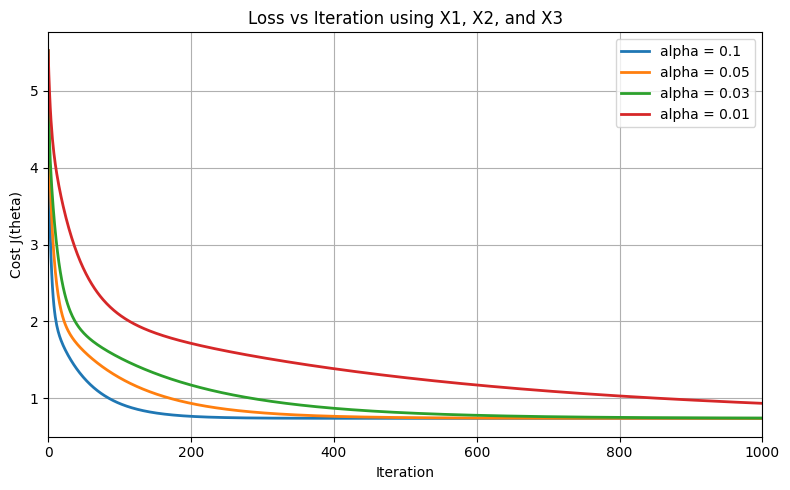



LEARNING RATE COMPARISON
alpha = 0.10: Final Loss = 0.738464, Iterations = 2008
alpha = 0.05: Final Loss = 0.738464, Iterations = 3885
alpha = 0.03: Final Loss = 0.738464, Iterations = 6310
alpha = 0.01: Final Loss = 0.738464, Iterations = 17844


PREDICTIONS
(X1, X2, X3) = (1, 1, 1) --> Predicted Y = 3.577409
(X1, X2, X3) = (2, 0, 4) --> Predicted Y = 0.244321
(X1, X2, X3) = (3, 2, 1) --> Predicted Y = 0.102534


In [1]:
# ============================================================
# PROBLEM 2
# Multiple Linear Regression using Gradient Descent
# Using X1, X2, and X3 together
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE AND LOAD DATA
# ============================================================

drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/ML Dataset/D3.csv"

df = pd.read_csv(file_path)

print("First five rows:")
print(df.head())


# ============================================================
# 2. EXTRACT X1, X2, X3, AND Y
# ============================================================

X1 = df.iloc[:, 0].values.astype(float)
X2 = df.iloc[:, 1].values.astype(float)
X3 = df.iloc[:, 2].values.astype(float)
Y  = df.iloc[:, 3].values.astype(float)

m = len(Y)


# ============================================================
# 3. CREATE DESIGN MATRIX
#
# Model:
# Y_hat = theta0 + theta1*X1 + theta2*X2 + theta3*X3
# ============================================================

X = np.column_stack((
    np.ones(m),
    X1,
    X2,
    X3
))


# ============================================================
# 4. COST FUNCTION
#
# J(theta) = (1 / 2m) * sum((Y_hat - Y)^2)
# ============================================================

def compute_cost(X, y, theta):

    m = len(y)

    predictions = X @ theta

    errors = predictions - y

    cost = (1 / (2 * m)) * np.sum(errors ** 2)

    return cost


# ============================================================
# 5. GRADIENT DESCENT FROM SCRATCH
# ============================================================

def gradient_descent(X, y, alpha, max_iterations=20000, tolerance=1e-10):

    m = len(y)

    # Initialize all theta parameters to zero
    theta = np.zeros(X.shape[1])

    loss_history = []

    for iteration in range(max_iterations):

        # Predictions
        predictions = X @ theta

        # Errors
        errors = predictions - y

        # Current loss
        loss = (1 / (2 * m)) * np.sum(errors ** 2)

        loss_history.append(loss)

        # Gradient
        gradient = (1 / m) * (X.T @ errors)

        # Update theta
        new_theta = theta - alpha * gradient

        # Check convergence
        if np.linalg.norm(new_theta - theta) < tolerance:

            theta = new_theta
            break

        theta = new_theta

    return theta, np.array(loss_history), iteration + 1


# ============================================================
# 6. LEARNING RATES TO EXPLORE
# ============================================================

learning_rates = [0.10, 0.05, 0.03, 0.01]

results = {}


# ============================================================
# 7. TRAIN MODEL FOR EACH LEARNING RATE
# ============================================================

print("\n")
print("=" * 70)
print("LEARNING RATE RESULTS")
print("=" * 70)


for alpha in learning_rates:

    theta, loss_history, iterations = gradient_descent(
        X,
        Y,
        alpha
    )

    final_loss = compute_cost(
        X,
        Y,
        theta
    )

    results[alpha] = {
        "theta": theta,
        "loss_history": loss_history,
        "iterations": iterations,
        "final_loss": final_loss
    }

    print(
        f"\nalpha = {alpha:.2f}"
    )

    print(
        f"Final Loss = {final_loss:.6f}"
    )

    print(
        f"Iterations = {iterations}"
    )

    print(
        f"theta0 = {theta[0]:.6f}"
    )

    print(
        f"theta1 = {theta[1]:.6f}"
    )

    print(
        f"theta2 = {theta[2]:.6f}"
    )

    print(
        f"theta3 = {theta[3]:.6f}"
    )


# ============================================================
# 8. REPORT FINAL LINEAR MODEL
#
# alpha = 0.10 is selected because it converges fastest
# among the tested learning rates while reaching the same
# final minimum loss.
# ============================================================

selected_alpha = 0.10

final_result = results[selected_alpha]

theta = final_result["theta"]


print("\n")
print("=" * 70)
print("FINAL LINEAR MODEL")
print("=" * 70)

print(
    f"\nY_hat = "
    f"{theta[0]:.6f} "
    f"+ ({theta[1]:.6f})X1 "
    f"+ ({theta[2]:.6f})X2 "
    f"+ ({theta[3]:.6f})X3"
)

print(
    f"\nFinal Loss = {final_result['final_loss']:.6f}"
)

print(
    f"Iterations = {final_result['iterations']}"
)


# ============================================================
# 9. PLOT LOSS OVER ITERATIONS
#
# Display only the first 1000 iterations for readability.
# Gradient descent itself still runs until convergence.
# ============================================================

plot_iterations = 1000

plt.figure(figsize=(8, 5))

for alpha in learning_rates:

    loss_history = results[alpha]["loss_history"]

    n = min(
        plot_iterations,
        len(loss_history)
    )

    plt.plot(
        range(n),
        loss_history[:n],
        linewidth=2,
        label=f"alpha = {alpha}"
    )

plt.xlabel("Iteration")

plt.ylabel("Cost J(theta)")

plt.title(
    "Loss vs Iteration using X1, X2, and X3"
)

plt.xlim(0, plot_iterations)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 10. REPORT LEARNING RATE EFFECT
# ============================================================

print("\n")
print("=" * 70)
print("LEARNING RATE COMPARISON")
print("=" * 70)


for alpha in learning_rates:

    print(
        f"alpha = {alpha:.2f}: "
        f"Final Loss = {results[alpha]['final_loss']:.6f}, "
        f"Iterations = {results[alpha]['iterations']}"
    )


# ============================================================
# 11. PREDICT Y FOR THE THREE REQUESTED POINTS
# ============================================================

new_points = np.array([
    [1, 1, 1],
    [2, 0, 4],
    [3, 2, 1]
], dtype=float)


# Add intercept column
new_X = np.column_stack((
    np.ones(len(new_points)),
    new_points
))


predictions = new_X @ theta


print("\n")
print("=" * 70)
print("PREDICTIONS")
print("=" * 70)


for point, prediction in zip(new_points, predictions):

    print(
        f"(X1, X2, X3) = "
        f"({point[0]:.0f}, "
        f"{point[1]:.0f}, "
        f"{point[2]:.0f}) "
        f"--> Predicted Y = {prediction:.6f}"
    )